In [2]:
import pandas as pd
import numpy as np

# Make results reproducible
np.random.seed(42)

# Number of orders
n = 500

# Create dataset
products = [
    "Laptop", "Smartphone", "Headphones", "Keyboard",
    "Mouse", "Monitor", "Tablet", "Smartwatch",
    "USB Cable", "Power Bank"
]

categories = {
    "Laptop": "Electronics",
    "Smartphone": "Electronics",
    "Headphones": "Accessories",
    "Keyboard": "Accessories",
    "Mouse": "Accessories",
    "Monitor": "Electronics",
    "Tablet": "Electronics",
    "Smartwatch": "Wearables",
    "USB Cable": "Accessories",
    "Power Bank": "Accessories"
}

prices = {
    "Laptop": 65000,
    "Smartphone": 30000,
    "Headphones": 2500,
    "Keyboard": 1800,
    "Mouse": 900,
    "Monitor": 15000,
    "Tablet": 22000,
    "Smartwatch": 7000,
    "USB Cable": 500,
    "Power Bank": 1800
}

regions = ["North", "South", "East", "West", "Central"]
payment_modes = ["UPI", "Credit Card", "Debit Card", "Cash on Delivery"]

data = []

for i in range(1, n + 1):
    product = np.random.choice(products)
    quantity = np.random.randint(1, 5)
    unit_price = prices[product]
    discount = np.random.choice([0, 5, 10, 15, 20])

    revenue = quantity * unit_price * (1 - discount / 100)

    # Approximate profit
    profit = revenue * np.random.uniform(0.08, 0.25)

    data.append([
        f"ORD{i:04d}",
        pd.Timestamp("2025-01-01") + pd.Timedelta(
            days=np.random.randint(0, 365)
        ),
        f"CUST{np.random.randint(1, 151):03d}",
        product,
        categories[product],
        np.random.choice(regions),
        quantity,
        unit_price,
        discount,
        round(revenue, 2),
        round(profit, 2),
        np.random.choice(payment_modes)
    ])

# Create DataFrame
df = pd.DataFrame(data, columns=[
    "Order_ID",
    "Order_Date",
    "Customer_ID",
    "Product",
    "Category",
    "Region",
    "Quantity",
    "Unit_Price",
    "Discount_Percent",
    "Revenue",
    "Profit",
    "Payment_Mode"
])

# Save CSV inside our project's data folder
file_path = r"D:\Career_Projects\04_Data_Analytics\Ecommerce_Sales_Analytics\data\ecommerce_sales.csv"

df.to_csv(file_path, index=False)

print("Dataset created successfully!")
print(f"Rows: {len(df)}")
print(f"Columns: {len(df.columns)}")
print(f"Saved to: {file_path}")

df.head()

Dataset created successfully!
Rows: 500
Columns: 12
Saved to: D:\Career_Projects\04_Data_Analytics\Ecommerce_Sales_Analytics\data\ecommerce_sales.csv


,Order_ID,Order_Date,Customer_ID,Product,Category,Region,Quantity,Unit_Price,Discount_Percent,Revenue,Profit,Payment_Mode
0,ORD0001,2025-03-13,CUST021,Tablet,Electronics,South,4,22000,20,70400.0,7827.35,Debit Card
1,ORD0002,2025-04-10,CUST104,Tablet,Electronics,East,3,22000,10,59400.0,13498.65,Credit Card
2,ORD0003,2025-07-11,CUST021,Mouse,Accessories,North,2,900,15,1530.0,366.52,Cash on Delivery
3,ORD0004,2025-02-18,CUST059,Power Bank,Accessories,South,2,1800,20,2880.0,441.88,Cash on Delivery
4,ORD0005,2025-05-11,CUST051,Headphones,Accessories,Central,4,2500,15,8500.0,1536.04,UPI


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_ID          500 non-null    str           
 1   Order_Date        500 non-null    datetime64[us]
 2   Customer_ID       500 non-null    str           
 3   Product           500 non-null    str           
 4   Category          500 non-null    str           
 5   Region            500 non-null    str           
 6   Quantity          500 non-null    int64         
 7   Unit_Price        500 non-null    int64         
 8   Discount_Percent  500 non-null    int64         
 9   Revenue           500 non-null    float64       
 10  Profit            500 non-null    float64       
 11  Payment_Mode      500 non-null    str           
dtypes: datetime64[us](1), float64(2), int64(3), str(6)
memory usage: 47.0 KB


In [4]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())


Missing values:
Order_ID            0
Order_Date          0
Customer_ID         0
Product             0
Category            0
Region              0
Quantity            0
Unit_Price          0
Discount_Percent    0
Revenue             0
Profit              0
Payment_Mode        0
dtype: int64

Duplicate rows:
0


In [21]:
df.dtypes

Order_ID                       str
Order_Date          datetime64[us]
Customer_ID                    str
Product                        str
Category                       str
Region                         str
Quantity                     int64
Unit_Price                   int64
Discount_Percent             int64
Revenue                    float64
Profit                     float64
Payment_Mode                   str
dtype: object

In [6]:
total_revenue = df["Revenue"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order_ID"].nunique()
total_quantity = df["Quantity"].sum()
average_order_value = df["Revenue"].mean()

print("===== E-COMMERCE SALES SUMMARY =====")
print(f"Total Revenue      : ₹{total_revenue:,.2f}")
print(f"Total Profit       : ₹{total_profit:,.2f}")
print(f"Total Orders       : {total_orders:,}")
print(f"Total Units Sold   : {total_quantity:,}")
print(f"Average Order Value: ₹{average_order_value:,.2f}")

===== E-COMMERCE SALES SUMMARY =====
Total Revenue      : ₹16,424,865.00
Total Profit       : ₹2,783,620.75
Total Orders       : 500
Total Units Sold   : 1,250
Average Order Value: ₹32,849.73


In [7]:
product_sales = (
    df.groupby("Product")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

print(product_sales)

Product
Laptop        7384000.0
Smartphone    3607500.0
Tablet        1871100.0
Monitor       1866750.0
Smartwatch     852950.0
Headphones     346750.0
Power Bank     196290.0
Keyboard       130410.0
Mouse          112815.0
USB Cable       56300.0
Name: Revenue, dtype: float64


In [8]:
category_sales = (
    df.groupby("Category")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

print(category_sales)

Category
Electronics    14729350.0
Wearables        852950.0
Accessories      842565.0
Name: Revenue, dtype: float64


In [9]:
region_sales = (
    df.groupby("Region")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

print(region_sales)

Region
North      3828990.0
West       3558010.0
South      3448775.0
Central    3060835.0
East       2528255.0
Name: Revenue, dtype: float64


In [10]:
monthly_sales = (
    df.groupby(df["Order_Date"].dt.to_period("M"))["Revenue"]
      .sum()
)

print(monthly_sales)

Order_Date
2025-01    1989670.0
2025-02    1487080.0
2025-03    1208170.0
2025-04     924450.0
2025-05    1593590.0
2025-06    1346895.0
2025-07    1325920.0
2025-08    1162180.0
2025-09     937160.0
2025-10    1229115.0
2025-11    1847650.0
2025-12    1372985.0
Freq: M, Name: Revenue, dtype: float64


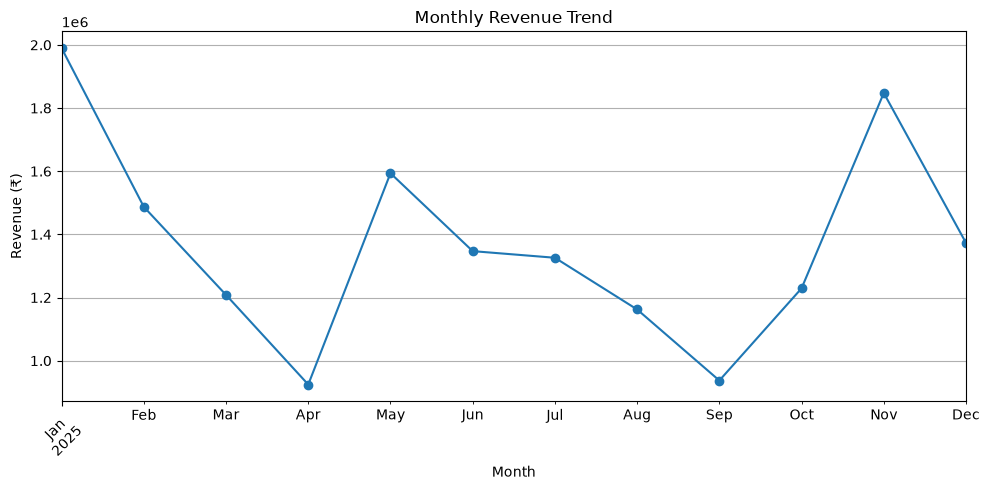

In [11]:
import matplotlib.pyplot as plt

monthly_sales.plot(
    kind="line",
    marker="o",
    figsize=(10, 5)
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [12]:
product_quantity = (
    df.groupby("Product")["Quantity"]
      .sum()
      .sort_values(ascending=False)
)

print(product_quantity)

Product
Headphones    151
Monitor       139
Mouse         138
Smartwatch    136
Smartphone    135
Laptop        128
USB Cable     127
Power Bank    119
Tablet         96
Keyboard       81
Name: Quantity, dtype: int64


In [13]:
product_analysis = (
    df.groupby("Product")
      .agg(
          Units_Sold=("Quantity", "sum"),
          Revenue=("Revenue", "sum")
      )
      .sort_values("Revenue", ascending=False)
)

print(product_analysis)

            Units_Sold    Revenue
Product                          
Laptop             128  7384000.0
Smartphone         135  3607500.0
Tablet              96  1871100.0
Monitor            139  1866750.0
Smartwatch         136   852950.0
Headphones         151   346750.0
Power Bank         119   196290.0
Keyboard            81   130410.0
Mouse              138   112815.0
USB Cable          127    56300.0


In [14]:
product_profit = (
    df.groupby("Product")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

print(product_profit)

Product
Laptop        1253204.51
Smartphone     624506.84
Monitor        321795.61
Tablet         314046.69
Smartwatch     131271.35
Headphones      58765.92
Power Bank      30454.25
Keyboard        20912.57
Mouse           19560.52
USB Cable        9102.49
Name: Profit, dtype: float64


In [15]:
product_profit_margin = (
    df.groupby("Product")
      .agg(
          Revenue=("Revenue", "sum"),
          Profit=("Profit", "sum")
      )
)

product_profit_margin["Profit_Margin_%"] = (
    product_profit_margin["Profit"]
    / product_profit_margin["Revenue"]
    * 100
)

product_profit_margin = product_profit_margin.sort_values(
    "Profit_Margin_%",
    ascending=False
)

print(product_profit_margin)

              Revenue      Profit  Profit_Margin_%
Product                                           
Mouse        112815.0    19560.52        17.338581
Smartphone  3607500.0   624506.84        17.311347
Monitor     1866750.0   321795.61        17.238281
Laptop      7384000.0  1253204.51        16.971892
Headphones   346750.0    58765.92        16.947634
Tablet      1871100.0   314046.69        16.784068
USB Cable     56300.0     9102.49        16.167833
Keyboard     130410.0    20912.57        16.036017
Power Bank   196290.0    30454.25        15.514927
Smartwatch   852950.0   131271.35        15.390275


In [16]:
customer_sales = (
    df.groupby("Customer_ID")
      .agg(
          Orders=("Order_ID", "nunique"),
          Revenue=("Revenue", "sum"),
          Profit=("Profit", "sum")
      )
      .sort_values("Revenue", ascending=False)
)

print(customer_sales.head(10))

             Orders   Revenue    Profit
Customer_ID                            
CUST126           6  464235.0  81029.34
CUST068           7  441955.0  75127.33
CUST056           4  373400.0  50656.67
CUST035           7  350395.0  64385.61
CUST022           4  346820.0  60157.05
CUST038           4  346025.0  56850.73
CUST046           6  304500.0  54034.85
CUST049           5  301640.0  49743.99
CUST070           4  298750.0  48716.05
CUST036           5  298370.0  65310.30


In [22]:
top_profit_customers = (
    customer_sales
    .sort_values("Profit", ascending=False)
    .head(10)
)

print(top_profit_customers)

             Orders   Revenue    Profit
Customer_ID                            
CUST126           6  464235.0  81029.34
CUST068           7  441955.0  75127.33
CUST036           5  298370.0  65310.30
CUST035           7  350395.0  64385.61
CUST022           4  346820.0  60157.05
CUST134           2  248000.0  59603.89
CUST038           4  346025.0  56850.73
CUST092           3  244840.0  55565.86
CUST046           6  304500.0  54034.85
CUST102           4  248175.0  52352.46


In [23]:
print("Quantity:")
print(df["Quantity"].describe())

print("\nDiscount:")
print(df["Discount_Percent"].describe())

print("\nRevenue:")
print(df["Revenue"].describe())

print("\nProfit:")
print(df["Profit"].describe())

Quantity:
count    500.000000
mean       2.500000
std        1.111968
min        1.000000
25%        2.000000
50%        2.500000
75%        3.000000
max        4.000000
Name: Quantity, dtype: float64

Discount:
count    500.000000
mean      10.220000
std        7.318382
min        0.000000
25%        5.000000
50%       10.000000
75%       15.000000
max       20.000000
Name: Discount_Percent, dtype: float64

Revenue:
count       500.000000
mean      32849.730000
std       50321.829475
min         400.000000
25%        2700.000000
50%        7750.000000
75%       45000.000000
max      260000.000000
Name: Revenue, dtype: float64

Profit:
count      500.000000
mean      5567.241500
std       9196.883898
min         37.070000
25%        407.352500
50%       1532.455000
75%       7836.645000
max      57174.760000
Name: Profit, dtype: float64
